In [9]:
import matplotlib
import statistics
import os
import sys
sys.path.append('..')
from er_simulator.wc_model import WCTaskSim, _process_peak
from er_simulator.functions import resample_signal
from er_simulator.synaptic_weights_matrices import normalize, generate_synaptic_weights_matrices
from er_simulator.read_utils import generate_sw_matrices_from_mat
from er_simulator.load_wc_params import load_wc_params
from er_simulator import functions
from er_simulator.boldIntegration import BWBoldModel
import numpy as np
from tqdm import tqdm 
from tqdm import trange
import matplotlib.pyplot as plt
from scipy import signal, stats, io
from scipy.io import savemat
from er_simulator.read_utils import get_project_root


matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 10
plt.rcParams['image.cmap'] = 'plasma'
np.set_printoptions(suppress=True)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
N = 1 # Sample size
microtime = 2/16
design = "07_EVENT_[2s_TR]_[100ms_DUR]_[6s_ISI]_[100_TRIALS]_[COACT]";
HRF_type = "[FixedHRF]"; # [VarHRF]

results_folder = f'{design}_{HRF_type}'
mat_path = os.path.join('..', '02_designs', f'{design}.mat')
config_file = os.path.join('..', '01_configs', f'{results_folder}.yaml')

## TASK time series

In [7]:
%%time
wc_sim = WCTaskSim.from_config(config_file)
wc_sim.generate_full_series(compute_bold=True)

CPU times: total: 5min 5s
Wall time: 4min 54s


In [19]:
# resample BOLD signal to MT resolution
task_BOLD_oscill_MT,task_time_MT = resample_signal(wc_sim.output['mtime'], wc_sim.output["BOLD"], wc_sim.mTime, microtime)

In [20]:
# remove beginning of the BOLD signal
shift = 35
task_BOLD_MT=task_BOLD_oscill_MT[0,shift:]
task_time_MT = task_time_MT[shift:]

In [21]:
# normalize BOLD signal
task_BOLD_MT = (task_BOLD_MT-statistics.mean(task_BOLD_MT))/max((task_BOLD_MT-statistics.mean(task_BOLD_MT)));

In [25]:
%%time
# compute envelopes
task_env_dict = wc_sim.compute_envelope_and_resample(wc_sim.output['syn_act'], srate=wc_sim.mTime, microtime=microtime)

CPU times: total: 7.11 s
Wall time: 7.12 s


In [48]:
%%time
# compute additional envelope
peak_int = 50
task_env_add = _process_peak(wc_sim.output['mtime'],wc_sim.output['syn_act'].T, wc_sim.mTime, peak_int, microtime)

CPU times: total: 1.2 s
Wall time: 1.19 s


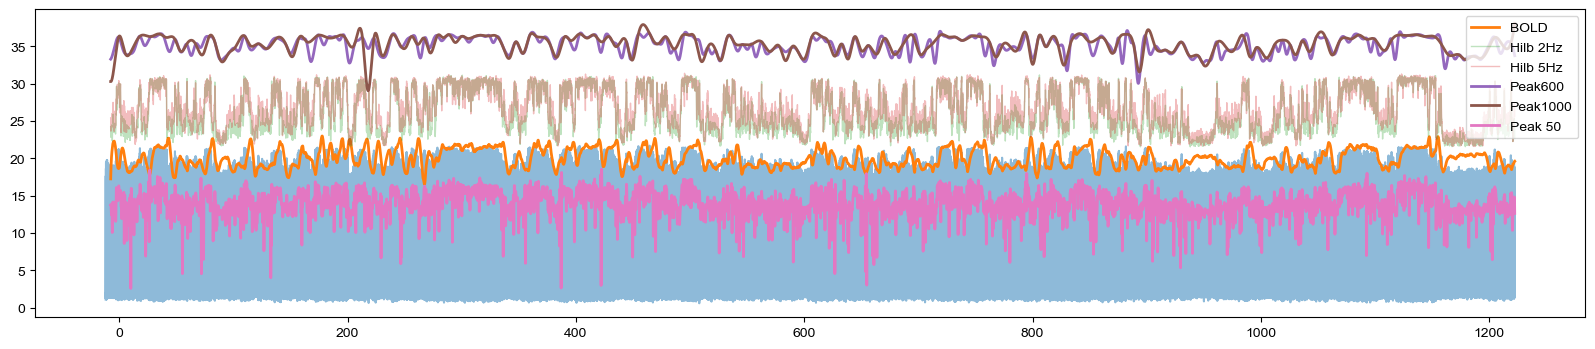

In [57]:
# plot TASK time series
plt.figure(figsize = (20,4))
# synaptic activity
plt.plot(wc_sim.output['mtime'][:],wc_sim.output['syn_act'][0,:], alpha=0.5)
# BOLD
plt.plot(task_time_MT, task_BOLD_MT*3+20, linewidth=2, label = 'BOLD')
# Envelopes
plt.plot(task_time_MT, task_env_dict['e_hil_d2'][0,shift:]+15, alpha=0.3, linewidth=1, label = 'Hilb 2Hz')
plt.plot(task_time_MT, task_env_dict['e_hil_d5'][0,shift:]+15, alpha=0.3, linewidth=1, label = 'Hilb 5Hz')
plt.plot(task_time_MT, task_env_dict['e_peak_600'][0,shift:]+15, alpha=1, linewidth=2, label = 'Peak600')
plt.plot(task_time_MT, task_env_dict['e_peak_1000'][0,shift:]+15, alpha=1, linewidth=2, label = 'Peak1000')
plt.plot(task_time_MT, task_env_add[0,shift:]-5, alpha=1, linewidth=2, label = f'Peak {peak_int}')

leg = plt.legend()

## REST time series

In [64]:
%%time
# Generate rest time-series in 5 ms resolution
output_rest = wc_sim.generate_rest_series(compute_bold=True, rest_duration=400)

CPU times: total: 1min 32s
Wall time: 1min 27s


In [65]:
# resample to MT
rest_BOLD_oscill_MT,rest_time_MT = resample_signal(output_rest['mtime'], output_rest["BOLD"], wc_sim.mTime, microtime)
# remove beggining
rest_MT=rest_BOLD_oscill_MT[0,shift:]
rest_t_mt = rest_time_MT[shift:]

In [66]:
# envelopes
env_dict_rest = wc_sim.compute_envelope_and_resample(output_rest['syn_act'], srate=wc_sim.mTime, microtime=microtime)
env_add_rest = _process_peak(output_rest['mtime'], output_rest['syn_act'].T, wc_sim.mTime, peak_int, microtime)

In [67]:
# normalize bold signal
rest_bold = (rest_MT-statistics.mean(rest_MT))/max((rest_MT-statistics.mean(rest_MT)));

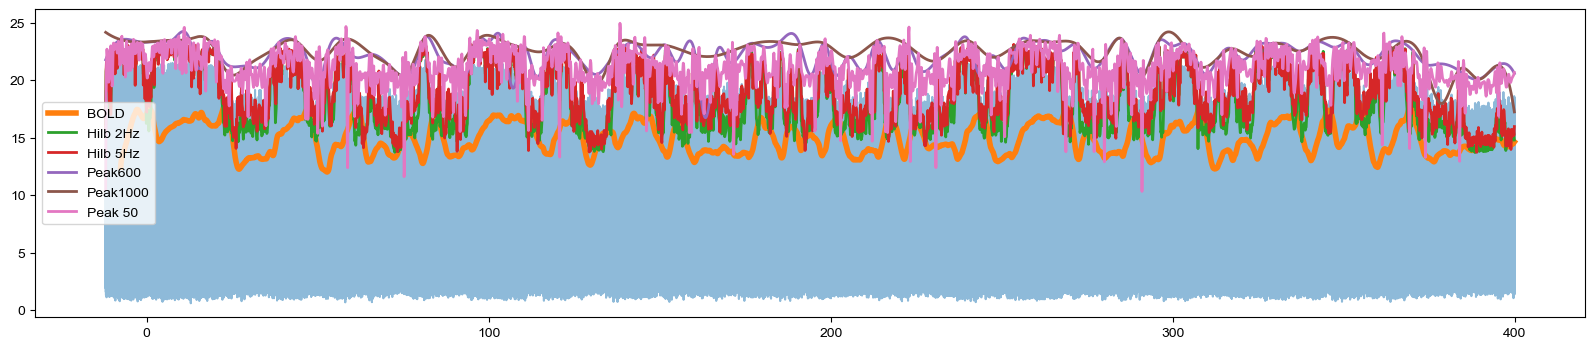

In [68]:
plt.figure(figsize = (20,4))
plt.plot(output_rest['mtime'][:],output_rest['syn_act'][0,:], alpha=0.5)
plt.plot(rest_t_mt,rest_bold*3+15,linewidth=4, label = 'BOLD')

plt.plot(rest_time_MT,env_dict_rest['e_hil_d2'][0,:]+7, alpha=1, linewidth=2, label = 'Hilb 2Hz')
plt.plot(rest_time_MT,env_dict_rest['e_hil_d5'][0,:]+7, alpha=1, linewidth=2, label = 'Hilb 5Hz')

plt.plot(rest_time_MT,env_dict_rest['e_peak_600'][0,:]+2, alpha=1, linewidth=2, label = 'Peak600')
plt.plot(rest_time_MT,env_dict_rest['e_peak_1000'][0,:]+2, alpha=1, linewidth=2, label = 'Peak1000')

plt.plot(rest_time_MT,env_add_rest[0,:]+2, alpha=1, linewidth=2, label = f'Peak {peak_int}')

leg = plt.legend()

# leftovers

In [ ]:
plt.figure(figsize = (12,6))
shift = 35
plt.subplot(231); plt.plot(env_dict['e_hil_d2'][0,shift:].T); plt.title("Envelope hilbert 38-42")
plt.subplot(232); plt.plot(env_dict['e_hil_d5'][0,shift:].T); plt.title("Envelope hilbert 35-45")
plt.subplot(233); plt.plot(task_BOLD_oscill_MT[0,shift:].T); plt.title("Bold Task")
plt.subplot(234); plt.plot(env_dict['e_peak_600'][0,shift:].T); plt.title("Envelope peak 600")
plt.subplot(235); plt.plot(env_dict['e_peak_1000'][0,shift:].T); plt.title("Envelope peak 1000")
plt.subplot(236); plt.plot(task_BOLD_oscill_MT[0,shift:].T); plt.title("Bold  Task");

In [ ]:
%%time
time_coact_mTime,_,task_BOLD_coact_mTime = wc_sim.generate_coactivation_by_mat(wc_sim.mat_path, dt=None, normalize_constant=1)
task_BOLD_coact_MT,_ =  resample_signal(time_coact_mTime, task_BOLD_coact_mTime, wc_sim.mTime, microtime)
len(task_BOLD_coact_mTime[0]), len(task_BOLD_coact_MT[0])

In [ ]:
plt.figure(figsize = (12,6))
plt.subplot(231); plt.plot(env_dict_rest['e_hil_d2'][0,:].T); plt.title("Envelope hilbert 38-42")
plt.subplot(232); plt.plot(env_dict_rest['e_hil_d5'][0,:].T); plt.title("Envelope hilbert 35-45")
plt.subplot(233); plt.plot(rest_BOLD_oscill_MT[0,40:].T); plt.title("Bold Rest")
plt.subplot(234); plt.plot(env_dict_rest['e_peak_600'][0,:].T);plt.title("Envelope peak 600")
plt.subplot(235); plt.plot(env_dict_rest['e_peak_1000'][0,:].T); plt.title("Envelope peak 1000")
plt.subplot(236); plt.plot(rest_BOLD_oscill_MT[0,40:].T); plt.title("Bold Rest")

## Поиграться с огибающими

Text(0.5, 1.0, 'Envelope peak {n}')

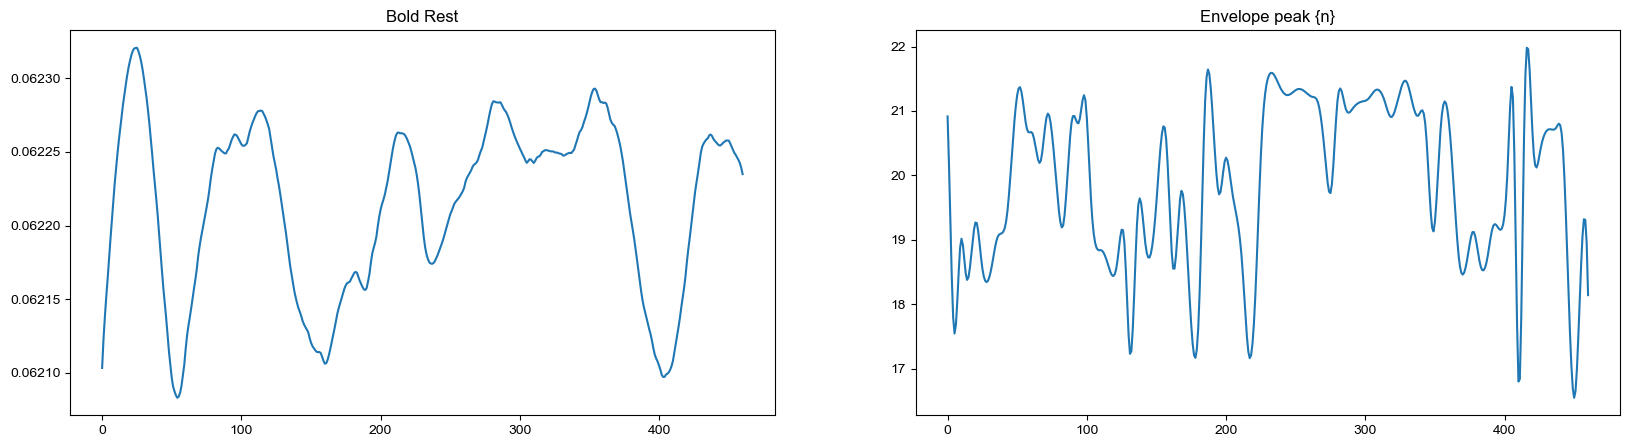

In [104]:
n = 100
env_p = _process_peak(output_rest['mtime'], output_rest['syn_act'].T, wc_sim.mTime, n, microtime)
plt.figure(figsize = (20,5))
plt.subplot(121); plt.plot(rest_BOLD_oscill_MT[0,shift:].T); plt.title("Bold Rest")
plt.subplot(122); plt.plot(env_p[0,shift:].T); plt.title("Envelope peak {n}")

# as a result for saving
dict_to_save = {**env_dict_rest, **env_dict, 
'task_BOLD_oscill_MT': task_BOLD_oscill_MT,
'BOLD_coact_MT':  task_BOLD_coact_MT,
'rest_BOLD_oscill_MT': rest_BOLD_oscill_MT}
dict_to_save.keys()
#maybe to TR also? 

In [43]:
for i in trange(N):
    
    # Create subject folder
    os.makedirs(os.path.join('..', '03_results', results_folder, fr'{i+1:03d}_Subject'), exist_ok=True)
    
    # Load simulation parameters from config file
    wc_sim = WCTaskSim.from_config(config_file)

    # Save HRF parameters
    wc_sim.boldModel.save_imp_with_params(os.path.join(fr'..', 
                                                       '03_results',
                                                       results_folder, 
                                                       fr'{i+1:03d}_Subject',
                                                       'HRF_params.mat'), s_type='mat')

    # Generate task time-series in 5 ms resolution
    wc_sim.generate_full_series(compute_bold=True)
    output_task = wc_sim.output.copy()

    # Downsample task BOLD to Micro-Time resolution = TR/16  
    task_BOLD_oscill_MT,_ = resample_signal(output_task['mtime'], output_task["BOLD"], wc_sim.mTime, microtime)

    # Generate co-activations in high resolution 10 ms
    time_coact,_,task_BOLD_coact_10ms = wc_sim.generate_coactivation_by_mat(wc_sim.mat_path, dt=0.005, normalize_constant=1)

    # Downsample co-activations to Micro-Time resolution = TR/16  
    task_BOLD_coact_MT,_ =  resample_signal(time_coact, task_BOLD_coact_10ms, 0.010, microtime)
    
    # Generate rest time-series in 5 ms resolution
    output_rest = wc_sim.generate_rest_series(compute_bold=True)

    # Downsample rest BOLD to Micro-Time resolution = TR/16
    rest_BOLD_oscill_MT,_ = resample_signal(output_rest['mtime'], output_rest["BOLD"], wc_sim.mTime, microtime)

    # Save time-series
    savemat(os.path.join(fr'..',
                         '03_results',
                         results_folder,
                         fr'{i+1:03d}_Subject',
                         'time_series.mat'),
                          {'task_syn_act_5ms':    output_task['syn_act'],
                           'task_BOLD_oscill_MT': task_BOLD_oscill_MT,
                           'BOLD_coact_MT':       task_BOLD_coact_MT,
                           'rest_syn_act_5ms':    output_rest['syn_act'],
                           'rest_BOLD_oscill_MT': rest_BOLD_oscill_MT}) 
    
    # Clear
    del output_task, task_BOLD_oscill_MT, task_BOLD_coact_MT, output_rest, wc_sim 
    

100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [08:12<00:00, 492.53s/it]
